In [5]:
import cdsapi
import pandas as pd

In [3]:
c = cdsapi.Client()
print("CDS API authentication successful")

CDS API authentication successful


In [48]:
dataset = "reanalysis-era5-single-levels"
request = {
    "product_type": ["reanalysis"],
    "variable": ["mean_sea_level_pressure"],
    "year": ["2024"],
    "month": [
        "06", "07", "09",
        "10"
    ],
    "day": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12",
        "13", "14", "15",
        "16", "17", "18",
        "19", "20", "21",
        "22", "23", "24",
        "25", "26", "27",
        "28", "29", "30",
        "31"
    ],
    "time": [
        "00:00", "01:00", "02:00",
        "03:00", "04:00", "05:00",
        "06:00", "07:00", "08:00",
        "09:00", "10:00", "11:00",
        "12:00", "13:00", "14:00",
        "15:00", "16:00", "17:00",
        "18:00", "19:00", "20:00",
        "21:00", "22:00", "23:00"
    ],
    "data_format": "netcdf",
    "download_format": "unarchived",
    "area": [50, 100, 0, 0]
}

client = cdsapi.Client()
client.retrieve(dataset, request).download()

2026-03-12 04:27:44,079 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-03-12 04:27:44,079 INFO Request ID is 2c3af33c-8833-4bb5-ba7e-98171eda0dd3
2026-03-12 04:27:44,166 INFO status has been updated to accepted
2026-03-12 04:27:58,031 INFO status has been updated to running
2026-03-12 04:34:03,354 INFO status has been updated to successful


8df31a57c66ba1da31b447ec2dd9400b.nc:   0%|          | 0.00/788M [00:00<?, ?B/s]

'8df31a57c66ba1da31b447ec2dd9400b.nc'

In [564]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [566]:
from netCDF4 import Dataset

Dataset("e1d7810ecd578995851fb2b581ec9581.nc")

<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    GRIB_centre: ecmf
    GRIB_centreDescription: European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre: 0
    Conventions: CF-1.7
    institution: European Centre for Medium-Range Weather Forecasts
    history: 2026-02-25T08:03 GRIB to CDM+CF via cfgrib-0.9.15.1/ecCodes-2.42.0 with {"source": "tmp_yzfn4cr/data.grib", "filter_by_keys": {"stream": ["oper"], "stepType": ["instant"]}, "encode_cf": ["parameter", "time", "geography", "vertical"]}
    dimensions(sizes): valid_time(2928), latitude(201), longitude(401)
    variables(dimensions): int64 number(), int64 valid_time(valid_time), float64 latitude(latitude), float64 longitude(longitude), <class 'str'> expver(valid_time), float32 sp(valid_time, latitude, longitude)
    groups: 

In [749]:
ds = xr.open_dataset("e1d7810ecd578995851fb2b581ec9581.nc")
ds

<xarray.Dataset> Size: 944MB
Dimensions:     (valid_time: 2928, latitude: 201, longitude: 401)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 23kB 2024-06-01 ... 2024-10-31T23...
  * latitude    (latitude) float64 2kB 50.0 49.75 49.5 49.25 ... 0.5 0.25 0.0
  * longitude   (longitude) float64 3kB -100.0 -99.75 -99.5 ... -0.5 -0.25 0.0
    number      int64 8B ...
    expver      (valid_time) <U4 47kB ...
Data variables:
    sp          (valid_time, latitude, longitude) float32 944MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-25T08:03 GRIB to CDM+CF via cfgrib-0.9.1...

In [1090]:
def get_local_sp(ds, center_lat, center_lon, radius=3):
    lat_min = center_lat - radius
    lat_max = center_lat + radius
    lon_min = center_lon - radius
    lon_max = center_lon + radius
    
    # Slice the dataset
    sp_local = ds['sp'].sel(
        latitude=slice(lat_max, lat_min),
        longitude=slice(lon_min, lon_max)
    )
    
    return sp_local

In [1092]:
hurricane_peaks = pd.DataFrame({
    'name': ['Helene', 'Oscar', 'Kirk', 'Beryl'],
    'date': ['2024-09-27', '2024-10-20', '2024-10-04', '2024-07-02'],
    'time': ['00:00', '22:00', '06:00', '09:45'],  # in UTC
    'lat': [28.7, 20.3, 21.9, 14.8],
    'lon': [-84.3, -74.4, -47.9, -67.2]
})

# Combine date and time into datetime
hurricane_peaks['datetime'] = pd.to_datetime(hurricane_peaks['date'] + ' ' + hurricane_peaks['time'])

In [1094]:
oscar = hurricane_peaks.iloc[3]
oscar

name                      Beryl
date                 2024-07-02
time                      09:45
lat                        14.8
lon                       -67.2
datetime    2024-07-02 09:45:00
Name: 3, dtype: object

In [1095]:

sp_local = get_local_sp(ds.sel(valid_time=oscar['datetime'], method='nearest'), 
                        oscar['lat'], oscar['lon'], radius=3)

sp_local_hPa = sp_local / 100.0

sp_local

<xarray.DataArray 'sp' (latitude: 24, longitude: 24)> Size: 2kB
array([[101314.125, 101240.125, 101274.125, ..., 101374.125, 101390.125,
        101409.125],
       [101194.125, 101198.125, 101250.125, ..., 101354.125, 101384.125,
        101398.125],
       [101182.125, 101266.125, 101226.125, ..., 101356.125, 101379.125,
        101385.125],
       ...,
       [100867.125, 100947.125, 100905.125, ..., 101174.125, 101193.125,
        101221.125],
       [100797.125, 100883.125, 100899.125, ..., 101181.125, 101186.125,
        101198.125],
       [100316.125, 100715.125, 101017.125, ..., 101162.125, 101184.125,
        101216.125]], shape=(24, 24), dtype=float32)
Coordinates:
  * latitude    (latitude) float64 192B 17.75 17.5 17.25 ... 12.5 12.25 12.0
  * longitude   (longitude) float64 192B -70.0 -69.75 -69.5 ... -64.5 -64.25
    number      int64 8B ...
    valid_time  datetime64[ns] 8B 2024-07-02T10:00:00
    expver      <U4 16B ...
Attributes: (12/32)
    GRIB_paramId:                             134
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      80601
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               Pa
    long_name:                                Surface pressure
    units:                                    Pa
    standard_name:                            surface_air_pressure
    GRIB_surface:                             0.0

In [1099]:
R = 6371.0

lat0 = oscar['lat']
lon0 = oscar['lon']

lat = np.deg2rad(sp_local.latitude.values)
lon = np.deg2rad(sp_local.longitude.values)
lat0 = np.deg2rad(lat0)
lon0 = np.deg2rad(lon0)

lon2d, lat2d = np.meshgrid(lon, lat)

dlat = lat2d - lat0
dlon = lon2d - lon0

a = np.sin(dlat/2)**2 + np.cos(lat0) * np.cos(lat2d) * np.sin(dlon/2)**2
c = 2 * np.arcsin(np.sqrt(a))

distance_km = R * c

In [1139]:
dist_flat = distance_km.flatten()
pressure_flat = sp_local_hPa.values.flatten()

bins = np.arange(0, np.max(dist_flat) + 1, 1)

bin_indices = np.digitize(dist_flat, bins)

In [1137]:
mean_pressure = np.array([
    pressure_flat[bin_indices == i].mean()
    for i in range(1, len(bins))
])

C:\Users\georg\AppData\Local\Temp\ipykernel_39588\1757701697.py:2: RuntimeWarning: Mean of empty slice.
  pressure_flat[bin_indices == i].mean()
C:\Users\georg\anaconda3\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


In [1102]:
mean_pressure = pd.Series(mean_pressure).interpolate().values

In [1104]:
mean_pressure_df = pd.DataFrame(mean_pressure)
mean_pressure_df.columns = ["SP"]
mean_pressure_df.to_csv(f"{oscar['name']}_pressure_average.csv")

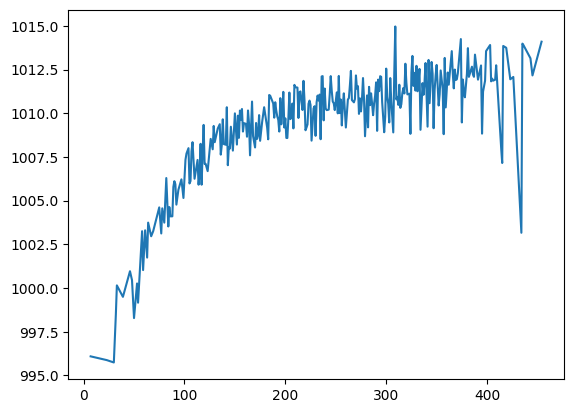

In [1105]:
x = np.arange(0,mean_pressure.size)

plt.plot(x, mean_pressure)
plt.show()

In [1106]:
mean_pressure_df.size

455

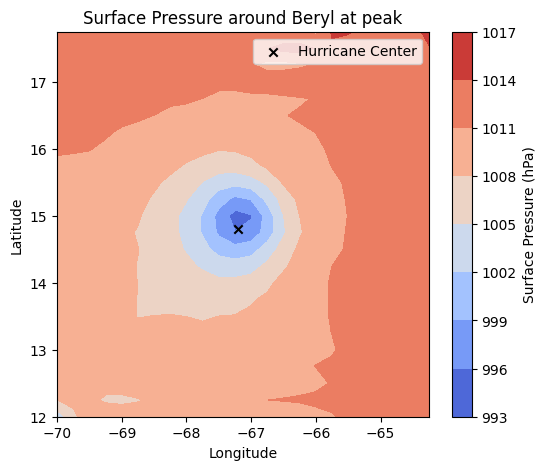

In [1107]:
plt.figure(figsize=(6,5))
plt.contourf(sp_local_hPa.longitude, sp_local_hPa.latitude, sp_local_hPa, cmap='coolwarm')
plt.colorbar(label='Surface Pressure (hPa)')
plt.scatter(oscar['lon'], oscar['lat'], color='black', marker='x', label='Hurricane Center')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f"Surface Pressure around {oscar['name']} at peak")
plt.legend()
plt.show()

<a list of 9 text.Text objects>

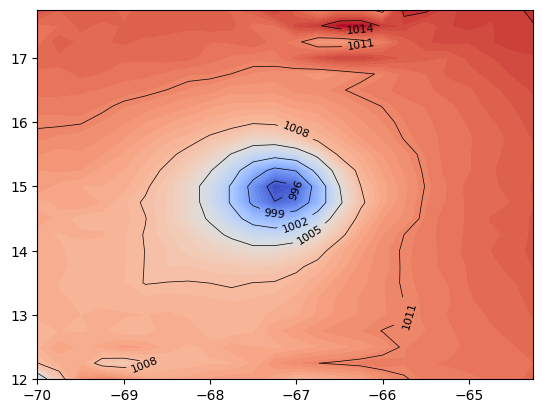

In [1108]:
plt.contourf(sp_local_hPa.longitude,
             sp_local_hPa.latitude,
             sp_local_hPa,
             levels=50,
             cmap='coolwarm')

cs = plt.contour(sp_local_hPa.longitude,
                 sp_local_hPa.latitude,
                 sp_local_hPa,
                 colors='black',
                 linewidths=0.5)

plt.clabel(cs, fontsize=8)

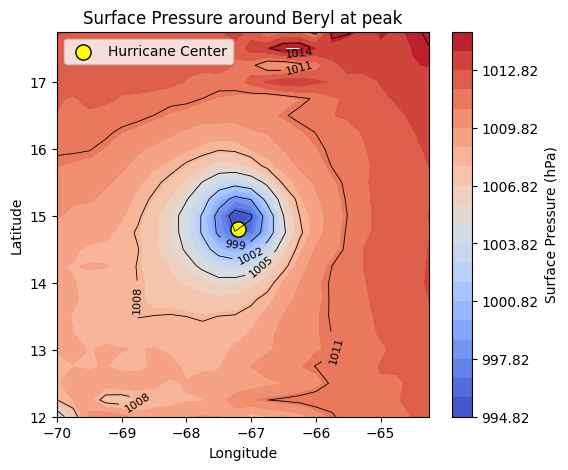

In [1109]:
plt.figure(figsize=(6,5))

levels = np.arange(sp_local_hPa.min(), sp_local_hPa.max(), 1)

cf = plt.contourf(sp_local_hPa.longitude, sp_local_hPa.latitude, sp_local_hPa, levels=levels, cmap='coolwarm')

cbar = plt.colorbar(cf)
cbar.set_label('Surface Pressure (hPa)')

cs = plt.contour(sp_local_hPa.longitude, sp_local_hPa.latitude, sp_local_hPa, colors='black', linewidths=0.6)

plt.clabel(cs, fontsize=8, inline=True)

plt.scatter(oscar['lon'], oscar['lat'], color='yellow', edgecolor='black', s=120, marker='o',label='Hurricane Center')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f"Surface Pressure around {oscar['name']} at peak")
plt.legend()
plt.savefig(f"pressure_plots/{oscar['name']}_pressure_around")
plt.show()

In [1113]:
import numpy as np

def quadrant_radial_profiles(sp_local, center_lat, center_lon, r_max=800, dr=10):
    """
    Compute radial mean profiles in NE/NW/SE/SW quadrants.

    Parameters
    ----------
    sp_local : xarray.DataArray
        2D pressure field with dimensions latitude x longitude
    center_lat, center_lon : float
        Storm center coordinates in degrees
    r_max : float
        Maximum radius in km
    dr : float
        Radial bin width in km

    Returns
    -------
    r_centers : 1D array
        Radial bin centers in km
    profiles : dict
        Quadrant pressure profiles: NE, NW, SE, SW
    """

    R = 6371.0

    lat_vals = sp_local.latitude.values
    lon_vals = sp_local.longitude.values

    lat = np.deg2rad(lat_vals)
    lon = np.deg2rad(lon_vals)
    lat0 = np.deg2rad(center_lat)
    lon0 = np.deg2rad(center_lon)

    lon2d, lat2d = np.meshgrid(lon, lat)

    dlat = lat2d - lat0
    dlon = lon2d - lon0

    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat0) * np.cos(lat2d) * np.sin(dlon / 2.0) ** 2
    c = 2.0 * np.arcsin(np.sqrt(a))
    distance_km = R * c

    # quadrant masks in degrees
    lon_deg2d, lat_deg2d = np.meshgrid(lon_vals, lat_vals)
    dlat_deg = lat_deg2d - center_lat
    dlon_deg = lon_deg2d - center_lon

    mask_NE = (dlat_deg >= 0) & (dlon_deg >= 0)
    mask_NW = (dlat_deg >= 0) & (dlon_deg < 0)
    mask_SE = (dlat_deg < 0) & (dlon_deg >= 0)
    mask_SW = (dlat_deg < 0) & (dlon_deg < 0)

    quadrant_masks = {
        'NE': mask_NE,
        'NW': mask_NW,
        'SE': mask_SE,
        'SW': mask_SW
    }

    field = sp_local.values

    r_km = np.arange(1, r_max + 1)
    
    profiles = {q: np.full(len(r_km), np.nan) for q in quadrant_masks}

    for q, qmask in quadrant_masks.items():
        for i, r in enumerate(r_km):
            r1 = r - 0.5
            r2 = r + 0.5
    
            radial_mask = (distance_km >= r1) & (distance_km < r2)
            mask = radial_mask & qmask
    
            vals = field[mask]
            vals = vals[~np.isnan(vals)]
    
            if len(vals) > 0:
                profiles[q][i] = np.mean(vals)
    
    return r_km, profiles

In [1076]:
r_centers, p_quads = quadrant_radial_profiles(
    sp_local,
    center_lat=oscar['lat'],
    center_lon=oscar['lon'],
    r_max=600,
    dr=1
)

In [1078]:
p_quads_interp = {
    q: pd.Series(p_quads[q]).interpolate(limit_area='inside').values
    for q in p_quads
}

In [1135]:
p_quads_interp_df = pd.DataFrame(p_quads_interp)
p_quads_interp_df['Distance'] = r_centers
p_quads_interp_df.to_csv(f"{oscar['name']}_pressure_average_quadrants.csv", index=False)